<div align="center">

<h1> <b> ANÁLISIS ESTADÍSTICO: ESTIMACIÓN, PRUEBAS DE HIPÓTESIS Y REGRESIÓN LINEAL </b> </h1>

</div>

<br>

<hr size=10 noshade color="green">
<p>
<p><img alt="UdeA logo" height="180px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="100px" vspace="4px"></p>

<div align="right">       

<h3><i> <b>Cristian Vergara Restrepo<br>
<b>Mateo Caballero Serna<br>
<b>Felipe Quitian Gallego<br>
</b> <br>
Universidad de Antioquia <br>
Instituto de Física  <br>
</i></h3>
</div>


---

## Introducción

Este notebook desarrolla seis ejercicios de estadística aplicada, organizados en tres bloques temáticos: estimación puntual e intervalos de confianza (puntos 1.A y 1.B), pruebas de hipótesis sobre la media con varianza conocida y desconocida (puntos 2.A y 2.B), y regresión lineal simple (puntos 3.A y 3.B). Los enunciados corresponden a ejercicios clásicos de inferencia estadística e ingeniería de la calidad, consistentes en estructura y datos con los propuestos por Montgomery y Runger (2018).

In [1]:
# Librerías utilizadas: manejo numérico y tabular, distribuciones de
# probabilidad y pruebas de hipótesis, regresión lineal y visualización.
import numpy as np
import pandas as pd
from scipy.stats import norm, t, ttest_1samp
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [2]:
def detectar_valores_atipicos(muestra):
    """
    Identifica valores atípicos en una muestra unidimensional mediante
    el criterio del rango intercuartílico (IQR).

    Un dato se considera atípico si es menor que Q1 - 1.5*IQR o mayor
    que Q3 + 1.5*IQR, donde Q1 y Q3 son el primer y el tercer cuartil
    de la muestra.

    Parameters
    ----------
    muestra : array_like
        Datos observados.

    Returns
    -------
    list
        Valores de la muestra que caen fuera del rango [Q1 - 1.5*IQR, Q3 + 1.5*IQR].
    """
    q1 = np.percentile(muestra, 25)
    q3 = np.percentile(muestra, 75)
    iqr = q3 - q1
    umbral_inferior = q1 - 1.5 * iqr
    umbral_superior = q3 + 1.5 * iqr
    return [valor.item() if hasattr(valor, "item") else valor
            for valor in muestra if valor < umbral_inferior or valor > umbral_superior]

## Punto 1.A — Límite elástico aparente

El límite elástico aparente ($l_e$) de un tipo de varilla se distribuye de forma normal, con desviación estándar poblacional conocida $\sigma = 5.25$ MPa a partir de pruebas extensas previas. Se dispone de una muestra de $n=18$ varillas para describir su comportamiento, verificar la presencia de valores atípicos y construir intervalos de confianza para la media poblacional a dos niveles de confianza distintos.

In [3]:
# Muestra del límite elástico aparente (MPa) y desviación estándar
# poblacional conocida.
le_muestra = np.array([444.7, 439.5, 448.1, 439.6, 444.3, 437.4, 448.9, 445.3, 442.8,
                        440.5, 441.4, 446.7, 437.3, 443.4, 445.4, 451.1, 439.5, 440.3])
n_le = len(le_muestra)
sigma_le = 5.25

### a. Media, varianza y curtosis muestrales

In [4]:
# La media y la varianza muestral (con divisor n-1, estimador insesgado)
# se calculan directamente sobre los datos. La curtosis se normaliza con
# la desviación estándar poblacional, ya que esta se reporta como un
# parámetro conocido y no como una cantidad a estimar.
media_le = np.mean(le_muestra)
varianza_le = np.var(le_muestra, ddof=1)
curtosis_le = np.sum((le_muestra - media_le)**4) / (n_le * sigma_le**4)

print(f"La media de la muestra es {media_le:.2f}")
print(f"La varianza de la muestra es {varianza_le:.2f}")
print(f"La curtosis de la muestra es {curtosis_le:.2f}")

La media de la muestra es 443.12
La varianza de la muestra es 15.98
La curtosis de la muestra es 0.65


### b. Detección de valores atípicos

In [5]:
atipicos_le = detectar_valores_atipicos(le_muestra)

if atipicos_le:
    print("Se encontraron valores atípicos:", atipicos_le)
else:
    print("No hay valores atípicos en la muestra.")

No hay valores atípicos en la muestra.


### c. Intervalo de confianza del 90 %

In [6]:
# Como la desviación estándar poblacional es conocida, el intervalo de
# confianza para la media se construye con el cuantil de la distribución normal.
alpha_le_90 = 0.10
z_le_90 = norm.ppf(1 - alpha_le_90 / 2)

limite_inf_90 = media_le - z_le_90 * (sigma_le / np.sqrt(n_le))
limite_sup_90 = media_le + z_le_90 * (sigma_le / np.sqrt(n_le))

intervalo_le_90 = (round(float(limite_inf_90), 2), round(float(limite_sup_90), 2))
print(f"El intervalo de confianza del 90% es {intervalo_le_90}")

El intervalo de confianza del 90% es (441.09, 445.16)


### d. Intervalo de confianza del 92 %

In [7]:
alpha_le_92 = 0.08
z_le_92 = norm.ppf(1 - alpha_le_92 / 2)

limite_inf_92 = media_le - z_le_92 * (sigma_le / np.sqrt(n_le))
limite_sup_92 = media_le + z_le_92 * (sigma_le / np.sqrt(n_le))

intervalo_le_92 = (round(float(limite_inf_92), 2), round(float(limite_sup_92), 2))
print(f"El intervalo de confianza del 92% es {intervalo_le_92}")

El intervalo de confianza del 92% es (440.96, 445.29)


Al pasar de un nivel de confianza del 90% al 92% el cuantil crítico $z_{\alpha/2}$ aumenta, por lo que el intervalo resultante es más ancho que el anterior, reflejando la mayor certeza exigida sobre la cobertura de la media poblacional.

## Punto 1.B — Grado de polimerización

El grado de polimerización de un polímero es el número de unidades repetitivas presentes en su estructura. Se cuenta con una muestra de 25 mediciones de este grado, a partir de la cual se estudia su distribución mediante un diagrama de caja y se construye un intervalo de confianza para el grado promedio verdadero.

In [8]:
# Muestra del grado de polimerización.
grado_muestra = np.array([417, 421, 396, 422, 409, 429, 411, 398,
                           406, 414, 414, 400, 404, 412, 412, 421,
                           392, 405, 408, 430, 405, 400, 401, 415, 398])
n_grado = len(grado_muestra)

media_grado = np.mean(grado_muestra)
varianza_grado = np.var(grado_muestra, ddof=1)

### a. Diagrama de caja

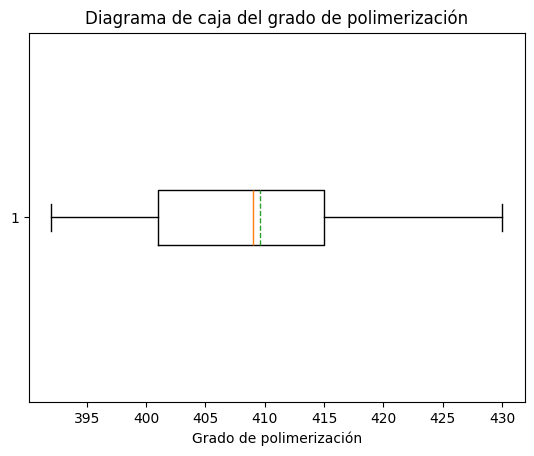

In [9]:
fig, ax = plt.subplots()
ax.boxplot(np.sort(grado_muestra), vert=False,
           flierprops=dict(marker="s", markerfacecolor="red"),
           showmeans=True, meanline=True)
ax.set_title('Diagrama de caja del grado de polimerización')
ax.set_xlabel('Grado de polimerización')
plt.show()

La línea discontinua dentro de la caja corresponde a la media muestral y la línea continua a la mediana; la caja contiene el 50% central de los datos. Ningún punto cae fuera de los bigotes, de modo que la muestra no presenta valores atípicos.

### b. Intervalo de confianza del 95 %

In [10]:
# La desviación estándar poblacional no es conocida, por lo que el
# intervalo se construye con la distribución t de Student.
alpha_grado = 0.05
gl_grado = n_grado - 1
t_grado_95 = t.ppf(1 - alpha_grado / 2, df=gl_grado)

limite_inf_grado = media_grado - t_grado_95 * np.sqrt(varianza_grado / n_grado)
limite_sup_grado = media_grado + t_grado_95 * np.sqrt(varianza_grado / n_grado)

intervalo_grado = (round(float(limite_inf_grado), 2), round(float(limite_sup_grado), 2))
print(f"El intervalo de confianza del 95% es {intervalo_grado}")

El intervalo de confianza del 95% es (405.43, 413.77)


### c. ¿Es factible un grado promedio de 440?

In [11]:
mu_grado = 440
t_obs_grado = (media_grado - mu_grado) / np.sqrt(varianza_grado / n_grado)

if abs(t_obs_grado) < t_grado_95:
    print(f"El valor de {mu_grado} es factible")
else:
    print("El valor promedio 440 no es factible")

El valor promedio 440 no es factible


## Punto 2.A — Materia orgánica en el suelo

Se midió el porcentaje de materia orgánica presente en 30 especímenes de suelo. El objetivo es determinar si estos datos sugieren que el porcentaje promedio verdadero difiere de 3%, mediante una prueba de hipótesis bilateral.

In [12]:
# Muestra del porcentaje de materia orgánica.
materia_muestra = np.array([1.10, 5.09, 0.97, 1.59, 4.60, 0.32, 0.55,
                             1.45, 0.14, 4.47, 1.20, 3.50, 5.02,
                             4.67, 5.22, 2.69, 3.98, 3.17, 3.03,
                             2.21, 0.69, 4.47, 3.31, 1.17, 0.76,
                             1.17, 1.57, 2.62, 1.66, 2.05])
n_materia = len(materia_muestra)

media_materia = np.mean(materia_muestra)
varianza_materia = np.var(materia_muestra, ddof=1)

### a y b. Prueba de hipótesis a un nivel de significancia de 0.10

In [13]:
# H0: mu = 3   vs   H1: mu != 3
alpha_materia_10 = 0.10
gl_materia = n_materia - 1
t_materia_10 = t.ppf(1 - alpha_materia_10 / 2, df=gl_materia)

mu_materia = 3
t_obs_materia = (media_materia - mu_materia) / np.sqrt(varianza_materia / n_materia)

if abs(t_obs_materia) < t_materia_10:
    print("Se acepta la hipótesis nula: los datos no son suficientes para sugerir "
          "que el porcentaje promedio verdadero es diferente de 3%.")
else:
    print("Se rechaza la hipótesis nula: los datos sugieren que el porcentaje "
          "promedio verdadero es diferente de 3%.")

Se rechaza la hipótesis nula: los datos sugieren que el porcentaje promedio verdadero es diferente de 3%.


### c. Valor p

In [14]:
_, p_valor_materia = ttest_1samp(materia_muestra, mu_materia)
print(f"El valor p es {p_valor_materia:.4f}")

El valor p es 0.0892


### d. Prueba de hipótesis a un nivel de significancia de 0.05

In [15]:
alpha_materia_05 = 0.05
t_materia_05 = t.ppf(1 - alpha_materia_05 / 2, df=gl_materia)

if abs(t_obs_materia) < t_materia_05:
    print("Se acepta la hipótesis nula: los datos no son suficientes para sugerir "
          "que el porcentaje promedio verdadero es diferente de 3%.")
else:
    print("Se rechaza la hipótesis nula: los datos sugieren que el porcentaje "
          "promedio verdadero es diferente de 3%.")

Se acepta la hipótesis nula: los datos no son suficientes para sugerir que el porcentaje promedio verdadero es diferente de 3%.


La conclusión sí cambia respecto al literal b. Como el valor p (≈0.089) es mayor que 0.05 pero menor que 0.10, la hipótesis nula se rechaza al nivel de significancia del 10% pero no se rechaza al nivel del 5%.

## Punto 2.B — Detectores de mercurio

Una muestra de 12 detectores de mercurio se expuso a un contenido de 1 mg del contaminante por kilogramo de alimento. Se evalúa si la lectura media poblacional de los detectores difiere de 1 mg, y se determina cuántas determinaciones habrían sido necesarias para detectar, con una potencia dada, una diferencia respecto a un valor medio alternativo de 0.95.

In [16]:
# Lecturas de los detectores de mercurio (mg).
mercurio_muestra = np.array([1.056, 0.909, 0.912, 0.969, 0.965,
                              0.913, 1.001, 1.050, 0.996, 1.077,
                              1.033, 0.924])
n_mercurio = len(mercurio_muestra)

media_mercurio = np.mean(mercurio_muestra)
varianza_mercurio = np.var(mercurio_muestra, ddof=1)

### a. Prueba de hipótesis a un nivel de significancia de 0.05

In [17]:
# H0: mu = 1   vs   H1: mu != 1
alpha_mercurio = 0.05
gl_mercurio = n_mercurio - 1
t_mercurio_05 = t.ppf(1 - alpha_mercurio / 2, df=gl_mercurio)

mu_mercurio = 1
t_obs_mercurio = (media_mercurio - mu_mercurio) / np.sqrt(varianza_mercurio / n_mercurio)

if abs(t_obs_mercurio) < t_mercurio_05:
    print("Se acepta la hipótesis nula: los datos no son suficientes para sugerir "
          "que la lectura media poblacional difiere de 1.")
else:
    print("Se rechaza la hipótesis nula: los datos sugieren que la lectura media "
          "poblacional es diferente de 1.")

Se acepta la hipótesis nula: los datos no son suficientes para sugerir que la lectura media poblacional difiere de 1.


### b. Tamaño de muestra requerido

In [18]:
# Tamaño de muestra necesario para una prueba bilateral sobre la media,
# suponiendo una desviación estándar sigma = 0.075, que garantice una
# probabilidad de error tipo II de beta = 0.10 al evaluar la alternativa
# mu = 0.95 frente a la hipótesis nula mu = 1 (diferencia a detectar:
# delta = |0.95 - 1|), usando el nivel de significancia alpha = 0.05
# empleado en el literal a.
sigma_supuesta = 0.075
beta_mercurio = 0.10
delta_mercurio = abs(0.95 - mu_mercurio)

z_alpha_2_mercurio = norm.ppf(1 - alpha_mercurio / 2)
z_beta_mercurio = norm.ppf(1 - beta_mercurio)

n_requerido = ((z_alpha_2_mercurio + z_beta_mercurio) * sigma_supuesta / delta_mercurio) ** 2

print(f"El tamaño de muestra requerido es n = {n_requerido:.2f}, "
      f"es decir, aproximadamente {int(np.ceil(n_requerido))} determinaciones.")

El tamaño de muestra requerido es n = 23.64, es decir, aproximadamente 24 determinaciones.


## Punto 3.A — Altura del local y precio de venta

El valor de un local comercial depende de numerosas variables, pero una investigadora recopiló datos que sugieren una relación simple entre su precio de venta y su altura. Se analiza la fuerza de esta relación y se ajusta un modelo de regresión lineal simple.

In [19]:
# Datos de altura (pies) y precio de venta (miles de dólares) de nueve locales.
altura = [24, 26, 26, 27, 28, 30, 30, 33, 36]
precio = [46.2, 50.35, 49.13, 48.07, 50.9, 54.8, 54.3, 57.17, 57.45]

tabla_local = pd.DataFrame({"Altura": altura, "Precio": precio})
tabla_local

,Altura,Precio
0,24,46.20
1,26,50.35
2,26,49.13
3,27,48.07
4,28,50.90
5,30,54.80
6,30,54.30
7,33,57.17
8,36,57.45


### a. Coeficiente de correlación

In [20]:
coef_corr_local = np.corrcoef(altura, precio)[0, 1]
print(f"El coeficiente de correlación es: {coef_corr_local:.4f}")

El coeficiente de correlación es: 0.9421


El coeficiente de correlación (r ≈ 0.94) indica que la altura y el precio no están exactamente relacionados, pero exhiben una fuerte correlación lineal positiva: a medida que aumenta la altura del local, su precio de venta tiende a aumentar también.

### b. Diagrama de dispersión

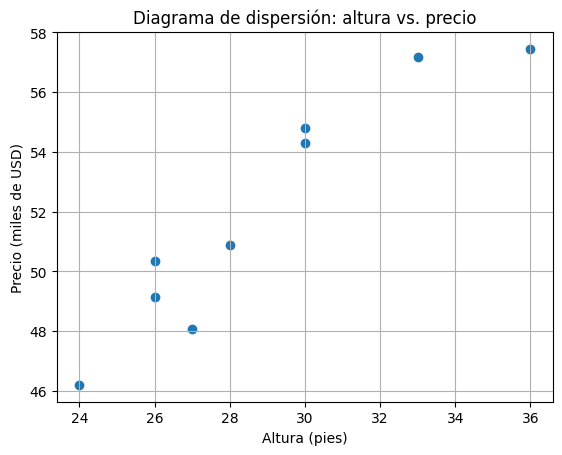

In [21]:
plt.scatter(altura, precio)
plt.title('Diagrama de dispersión: altura vs. precio')
plt.xlabel('Altura (pies)')
plt.ylabel('Precio (miles de USD)')
plt.grid(True)
plt.show()

El diagrama de dispersión confirma la tendencia lineal creciente sugerida por el coeficiente de correlación.

### c. Recta de mínimos cuadrados

La ecuación de la recta es: y = 1.01x + 23.00


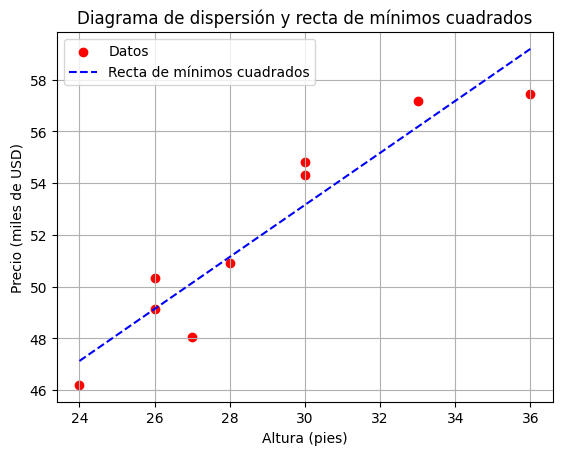

In [22]:
altura_np = np.array(altura)
precio_np = np.array(precio)
n_local = len(altura)

suma_x = np.sum(altura_np)
suma_y = np.sum(precio_np)
suma_xy = np.sum(altura_np * precio_np)
suma_x2 = np.sum(altura_np ** 2)

# Pendiente e intercepto de la recta de mínimos cuadrados.
pendiente_local = (n_local * suma_xy - suma_x * suma_y) / (n_local * suma_x2 - suma_x ** 2)
intercepto_local = (suma_y - pendiente_local * suma_x) / n_local

print(f"La ecuación de la recta es: y = {pendiente_local:.2f}x + {intercepto_local:.2f}")

x_recta = np.linspace(altura[0], altura[-1], 100)
plt.scatter(altura, precio, color="red", label="Datos")
plt.plot(x_recta, pendiente_local * x_recta + intercepto_local,
         linestyle="--", color="blue", label="Recta de mínimos cuadrados")
plt.title('Diagrama de dispersión y recta de mínimos cuadrados')
plt.xlabel('Altura (pies)')
plt.ylabel('Precio (miles de USD)')
plt.legend()
plt.grid(True)
plt.show()

### d. Predicción puntual y residuo

In [23]:
altura_prediccion = 27
precio_prediccion = pendiente_local * altura_prediccion + intercepto_local

# Residuo respecto al precio observado para esa misma altura.
indice_altura = altura.index(altura_prediccion)
residuo_local = abs(precio_prediccion - precio[indice_altura])

print(f"Para una altura de {altura_prediccion} pies, la predicción del precio es de {precio_prediccion:.2f}")
print(f"El residuo (error del modelo) es {residuo_local:.2f}")

Para una altura de 27 pies, la predicción del precio es de 50.14
El residuo (error del modelo) es 2.07


### e. Coeficiente de determinación

In [24]:
residuos_local = precio_np - (pendiente_local * altura_np + intercepto_local)

SSR_local = np.sum(residuos_local ** 2)
SST_local = np.sum((precio_np - np.mean(precio_np)) ** 2)

r_cuadrado_local = 1 - (SSR_local / SST_local)
print(f"El {r_cuadrado_local * 100:.2f}% de la variación observada del precio puede "
      f"ser atribuido a la relación lineal aproximada con la altura.")

El 88.76% de la variación observada del precio puede ser atribuido a la relación lineal aproximada con la altura.


## Punto 3.B — Gases atmosféricos: CO y NOy

Un grupo de investigadores midió, a una misma altura en una ciudad, las variaciones de monóxido de carbono (ΔCO) y de óxidos de nitrógeno (ΔNOy). Se ajusta un modelo lineal simple para relacionar ambas variables, se utiliza para pronosticar ΔNOy, y se evalúa el efecto de una observación con un valor de ΔCO inusualmente alto sobre la ecuación ajustada.

In [25]:
# Variaciones de monóxido de carbono (ΔCO, ppb) y de óxidos de nitrógeno
# (ΔNOy, ppb) medidas en una misma ciudad.
CO = np.array([50, 60, 95, 108, 135, 210, 214, 315, 720])
NOy = np.array([2.3, 4.5, 4.0, 3.7, 8.2, 5.4, 7.2, 13.8, 32.1])

### a. Ajuste del modelo lineal

El coeficiente de correlación es: 0.9790
La ecuación de la recta ajustada es: y = 0.0436x - 0.2204


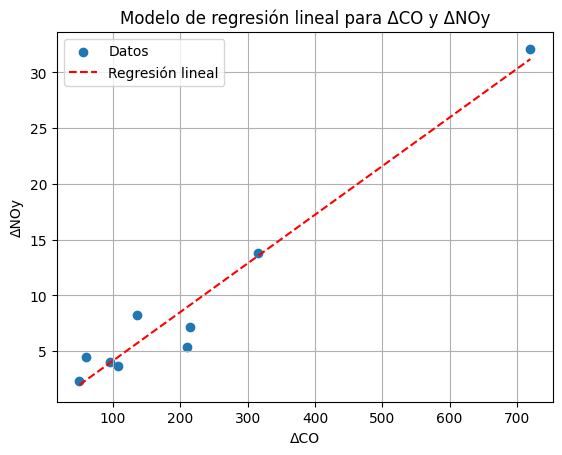

In [26]:
X_gases = CO.reshape(-1, 1)
modelo_gases = LinearRegression().fit(X_gases, NOy)
predicciones_gases = modelo_gases.predict(X_gases)

coef_corr_gases = np.corrcoef(CO, NOy)[0, 1]
print(f"El coeficiente de correlación es: {coef_corr_gases:.4f}")
signo_gases = "+" if modelo_gases.intercept_ >= 0 else "-"
print(f"La ecuación de la recta ajustada es: y = {modelo_gases.coef_[0]:.4f}x {signo_gases} {abs(modelo_gases.intercept_):.4f}")

plt.scatter(CO, NOy, label='Datos')
plt.plot(CO, predicciones_gases, color='red', linestyle='--', label='Regresión lineal')
plt.xlabel('ΔCO')
plt.ylabel('ΔNOy')
plt.title('Modelo de regresión lineal para ΔCO y ΔNOy')
plt.grid(True)
plt.legend()
plt.show()

El coeficiente de correlación (r ≈ 0.98) sugiere una relación lineal positiva fuerte entre ambas variables, adecuadamente descrita por el modelo lineal simple ajustado.

### b. Pronóstico para ΔCO = 400

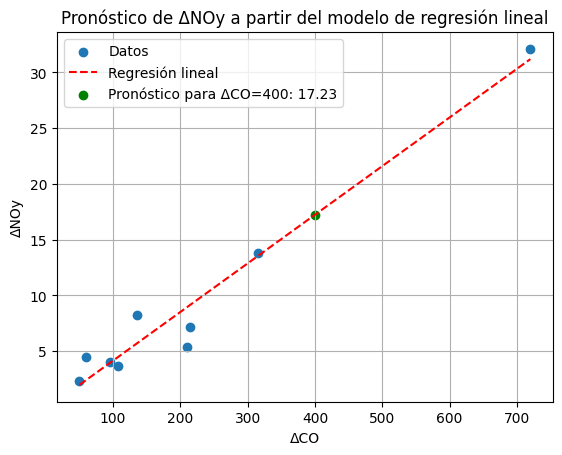

El pronóstico para ΔNOy cuando ΔCO=400 es ΔNOy=17.23
El error cuadrático medio en el conjunto de entrenamiento es 3.19


In [27]:
CO_nuevo = np.array([[400]])
prediccion_400 = modelo_gases.predict(CO_nuevo)
mse_gases = mean_squared_error(NOy, predicciones_gases)

plt.scatter(CO, NOy, label='Datos')
plt.plot(CO, predicciones_gases, color='red', linestyle='--', label='Regresión lineal')
plt.scatter(400, prediccion_400, color='green',
            label=f'Pronóstico para ΔCO=400: {prediccion_400[0]:.2f}')
plt.xlabel('ΔCO')
plt.ylabel('ΔNOy')
plt.title('Pronóstico de ΔNOy a partir del modelo de regresión lineal')
plt.grid(True)
plt.legend()
plt.show()

print(f"El pronóstico para ΔNOy cuando ΔCO=400 es ΔNOy={prediccion_400[0]:.2f}")
print(f"El error cuadrático medio en el conjunto de entrenamiento es {mse_gases:.2f}")

El error cuadrático medio en el conjunto de entrenamiento (≈3.19) indica una dispersión considerable de los datos alrededor de la recta ajustada, por lo que el pronóstico puntual no puede considerarse muy preciso, aunque sí es consistente con la tendencia lineal creciente observada entre las dos variables.

### c. Efecto del valor atípico

In [28]:
atipicos_gases = detectar_valores_atipicos(CO)

if atipicos_gases:
    print(f"Se encontró que {atipicos_gases} es un valor atípico")
else:
    print("No hay valores atípicos en la muestra.")

Se encontró que [720] es un valor atípico


Sí, ΔCO = 720 se considera un valor atípico según el criterio del rango intercuartílico, al ser mucho más grande que el resto de las observaciones.

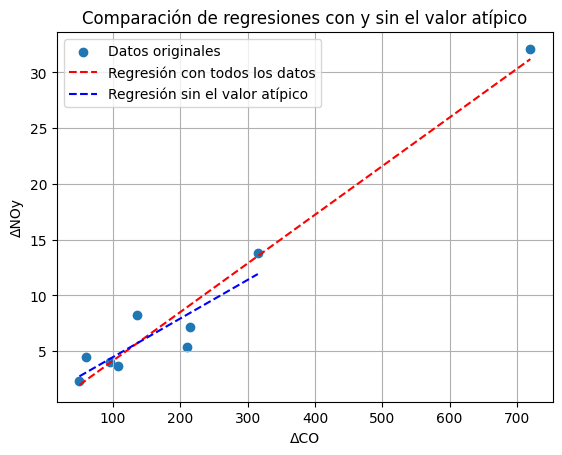

In [29]:
# Comparación del ajuste con y sin el valor atípico.
X_sin_atipico = CO[:-1].reshape(-1, 1)
NOy_sin_atipico = NOy[:-1]
modelo_sin_atipico = LinearRegression().fit(X_sin_atipico, NOy_sin_atipico)

plt.scatter(CO, NOy, label='Datos originales')
plt.plot(CO, modelo_gases.predict(X_gases), color='red', linestyle='--',
         label='Regresión con todos los datos')
plt.plot(CO[:-1], modelo_sin_atipico.predict(X_sin_atipico), color='blue', linestyle='--',
         label='Regresión sin el valor atípico')
plt.xlabel('ΔCO')
plt.ylabel('ΔNOy')
plt.title('Comparación de regresiones con y sin el valor atípico')
plt.grid(True)
plt.legend()
plt.show()

Al comparar ambas rectas se observa una diferencia notable en la pendiente estimada (0.0436 con todos los datos frente a 0.0346 al excluir el valor atípico), lo que confirma que esta observación tiene un impacto sustancial sobre la ecuación ajustada.

## Referencias

**Fuente académica primaria**

Montgomery, D. C., & Runger, G. C. (2018). *Applied statistics and probability for engineers* (7th ed.). Wiley. No fue posible confirmar con certeza la edición exacta de la que provienen los enunciados de este parcial, pero su estructura y sus datos son consistentes con los ejercicios de estimación, pruebas de hipótesis y regresión lineal simple de este texto.

**Recursos complementarios (herramientas computacionales)**

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., del Río, J. F., Wiebe, M., Peterson, P., ... Oliphant, T. E. (2020). Array programming with NumPy. *Nature, 585*, 357–362.

McKinney, W. (2010). Data structures for statistical computing in Python. In *Proceedings of the 9th Python in Science Conference* (pp. 56–61).

Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S. J., Brett, M., Wilson, J., Millman, K. J., Mayorov, N., Nelson, A. R. J., Jones, E., Kern, R., Larson, E., ... van Mulbregt, P. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods, 17*, 261–272.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90–95.